# Phase 1 (ResNet18)

In [31]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

# Set device to GPU (Make sure to change your Colab runtime to T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transformations (Resizing to 96x96 as recommended)
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    # Standard ImageNet normalization values
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize pre-trained ResNet-18
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Modify the final fully connected layer for 100 Mini-ImageNet classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 100)
model = model.to(device)

print("Model initialized and adapted for 100 classes.")

Using device: cuda
Model initialized and adapted for 100 classes.


In [32]:
!mkdir -p mini_imagenet
!tar -xf train.tar -C mini_imagenet/
!tar -xf val.tar -C mini_imagenet/
!tar -xf test.tar -C mini_imagenet/

In [33]:

data_dir = './mini_imagenet'

# Create Datasets
train_dataset = ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
val_dataset = ImageFolder(os.path.join(data_dir, 'val'), transform=transform)
test_dataset = ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Loaded {len(train_dataset)} training, {len(val_dataset)} validation, and {len(test_dataset)} test images.")



Loaded 38400 training, 9600 validation, and 12000 test images.


The dataset size need adjustments to be 50000 training images and 10000 test images

In [34]:
import os
import shutil
import glob

# Define our paths
old_base = './mini_imagenet'
new_base = './mini_imagenet_fixed'
new_train = os.path.join(new_base, 'train')
new_test = os.path.join(new_base, 'test')

# Create new directories
os.makedirs(new_train, exist_ok=True)
os.makedirs(new_test, exist_ok=True)

# 1. Find all 100 class folders across train, val, and test
all_classes = []
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(old_base, split)
    if os.path.exists(split_dir):
        classes = [os.path.join(split_dir, d) for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        all_classes.extend(classes)

print(f"Found {len(all_classes)} total classes. Reorganizing...")

# 2. For each class, allocate 500 images to train, 100 to test
for class_path in all_classes:
    class_name = os.path.basename(class_path)

    # Create corresponding class folders in the new fixed directory
    os.makedirs(os.path.join(new_train, class_name), exist_ok=True)
    os.makedirs(os.path.join(new_test, class_name), exist_ok=True)

    # Get all 600 images in this class
    images = glob.glob(os.path.join(class_path, '*.*'))
    images.sort() # Sort to ensure consistent splitting

    # Split them per the project guidelines
    train_imgs = images[:500]
    test_imgs = images[500:]

    # Copy files to their new homes
    for img in train_imgs:
        shutil.copy(img, os.path.join(new_train, class_name, os.path.basename(img)))
    for img in test_imgs:
        shutil.copy(img, os.path.join(new_test, class_name, os.path.basename(img)))

print("Data successfully reorganized! Update your DataLoader data_dir to './mini_imagenet_fixed'")

Found 100 total classes. Reorganizing...
Data successfully reorganized! Update your DataLoader data_dir to './mini_imagenet_fixed'


In [37]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

data_dir = './mini_imagenet_fixed'

# 1. Load the full fixed training folder and the test folder
full_train_dataset = ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
test_dataset = ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

# 2. Define the split sizes (80% train, 20% validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# 3. Randomly split the training dataset
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 4. Create the final DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Loaded {len(train_dataset)} training, {len(val_dataset)} validation, and {len(test_dataset)} test images.")

Loaded 40000 training, 10000 validation, and 10000 test images.


Fixed correctly

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# 1. Define the Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
# Adam is a solid default optimizer for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 5 # Starting with 5 epochs for a test run
best_val_acc = 0.0

print(f"Starting training on device: {device}...")

# 2. The Main Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        # Move data to the GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the gradients, forward pass, backward pass, optimize
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Track training statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Disable gradient calculation for validation (saves memory/time)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track validation statistics
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    # Print epoch results
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.0f}s | "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%  "
    )

    # Save the model if it's the best one we've seen so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_baseline.pth')
        print("  --> Saved new best model!")

print("Finished Training Baseline Model.")

Starting training on device: cuda...
Epoch [1/5] | Time: 46s | Train Loss: 1.8655, Train Acc: 56.00%  
  --> Saved new best model!
Epoch [2/5] | Time: 46s | Train Loss: 0.7670, Train Acc: 79.96%  
  --> Saved new best model!
Epoch [3/5] | Time: 47s | Train Loss: 0.3246, Train Acc: 92.27%  
  --> Saved new best model!
Epoch [4/5] | Time: 46s | Train Loss: 0.1113, Train Acc: 98.11%  
  --> Saved new best model!
Epoch [5/5] | Time: 47s | Train Loss: 0.0421, Train Acc: 99.60%  
  --> Saved new best model!
Finished Training Baseline Model.


In [39]:
# Load the best weights we just saved
model.load_state_dict(torch.load('best_resnet18_baseline.pth'))
model.eval() # Set to evaluation mode

correct_test = 0
total_test = 0

print("Evaluating baseline model on the uncompressed test set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_acc = 100 * correct_test / total_test
print(f"Baseline Test Accuracy: {test_acc:.2f}%")

Evaluating baseline model on the uncompressed test set...
Baseline Test Accuracy: 69.90%


# Phase 2 (ResNet18)

In [40]:
import pywt
import numpy as np
import torch

def compress_image_wavelet(image_tensor, ratio):
    """
    Compresses a PyTorch image tensor using 2D Haar Wavelet transform.
    Applies hard thresholding based on the desired compression ratio.
    """
    # Convert tensor to numpy array [C, H, W]
    img_np = image_tensor.cpu().numpy()
    C, H, W = img_np.shape

    compressed_img = np.zeros_like(img_np)

    # Process each color channel (RGB) separately
    for c in range(C):
        channel = img_np[c]

        # Perform 2D Discrete Wavelet Transform
        coeffs = pywt.dwt2(channel, 'haar')
        cA, (cH, cV, cD) = coeffs

        # Flatten all coefficients to find the threshold value
        all_coeffs = np.concatenate((cA.flatten(), cH.flatten(), cV.flatten(), cD.flatten()))

        # Calculate how many coefficients to keep based on the ratio
        total_coeffs = len(all_coeffs)
        kept_coeffs = max(1, int(total_coeffs / ratio)) # Keep at least 1 to avoid errors

        # Find the threshold value (the value below which we zero out)
        sorted_abs_coeffs = np.sort(np.abs(all_coeffs))
        threshold = sorted_abs_coeffs[-kept_coeffs]

        # Apply hard thresholding (zero out coefficients below threshold)
        cA_thresh = pywt.threshold(cA, threshold, mode='hard')
        cH_thresh = pywt.threshold(cH, threshold, mode='hard')
        cV_thresh = pywt.threshold(cV, threshold, mode='hard')
        cD_thresh = pywt.threshold(cD, threshold, mode='hard')

        # Reconstruct the channel using Inverse DWT
        reconstructed_channel = pywt.idwt2((cA_thresh, (cH_thresh, cV_thresh, cD_thresh)), 'haar')

        # Put back into our image array
        compressed_img[c] = reconstructed_channel[:H, :W]

    return torch.from_numpy(compressed_img).float()


# --- Evaluate Model on Compressed Images ---
compression_ratios = [2, 5, 10]

print("Starting Wavelet Compression Evaluation...")

for ratio in compression_ratios:
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader: # Using your fixed test_loader

            # Compress the batch of images one by one
            compressed_inputs = torch.stack([compress_image_wavelet(img, ratio) for img in inputs])

            # Move compressed images and labels to GPU
            compressed_inputs = compressed_inputs.to(device)
            labels = labels.to(device)

            # Run model predictions
            outputs = model(compressed_inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Compression Ratio {ratio}:1 -> Test Accuracy: {accuracy:.2f}%")

Starting Wavelet Compression Evaluation...
Compression Ratio 2:1 -> Test Accuracy: 69.81%
Compression Ratio 5:1 -> Test Accuracy: 47.21%
Compression Ratio 10:1 -> Test Accuracy: 13.43%


In [45]:
import torch

def analyze_class_degradation(model, test_loader, class_names, ratio=10):
    print(f"Starting per-class analysis at {ratio}:1 compression ratio. This might take a few minutes...")
    model.eval()

    # Dictionaries to track correct predictions
    correct_base = {classname: 0 for classname in class_names}
    correct_comp = {classname: 0 for classname in class_names}
    total_class = {classname: 0 for classname in class_names}

    with torch.no_grad():
        for inputs, labels in test_loader:
            # 1. Evaluate uncompressed batch
            inputs, labels = inputs.to(device), labels.to(device)
            outputs_base = model(inputs)
            _, preds_base = torch.max(outputs_base, 1)

            # 2. Evaluate compressed batch
            comp_inputs = torch.stack([compress_image_wavelet(img, ratio) for img in inputs]).to(device)
            outputs_comp = model(comp_inputs)
            _, preds_comp = torch.max(outputs_comp, 1)

            # 3. Tally results per class
            for label, p_base, p_comp in zip(labels, preds_base, preds_comp):
                classname = class_names[label.item()]
                total_class[classname] += 1

                if p_base == label:
                    correct_base[classname] += 1
                if p_comp == label:
                    correct_comp[classname] += 1

    # Calculate the accuracy drop for each class
    class_drops = {}
    for classname in class_names:
        if total_class[classname] > 0: # Avoid division by zero
            acc_base = 100 * correct_base[classname] / total_class[classname]
            acc_comp = 100 * correct_comp[classname] / total_class[classname]
            class_drops[classname] = {
                'base_acc': acc_base,
                'comp_acc': acc_comp,
                'drop': acc_base - acc_comp
            }

    # Sort the dictionary by the highest drop in accuracy
    sorted_drops = sorted(class_drops.items(), key=lambda x: x[1]['drop'], reverse=True)

    print("\n--- TOP 5 MOST AFFECTED CLASSES ---")
    for classname, stats in sorted_drops[:5]:
        print(f"Class: {classname:15s} | Drop: {stats['drop']:5.1f}% (Base: {stats['base_acc']:4.1f}% -> Comp: {stats['comp_acc']:4.1f}%)")

    print("\n--- TOP 5 MOST ROBUST CLASSES ---")
    for classname, stats in sorted_drops[-5:]:
        print(f"Class: {classname:15s} | Drop: {stats['drop']:5.1f}% (Base: {stats['base_acc']:4.1f}% -> Comp: {stats['comp_acc']:4.1f}%)")

# Extract class names from your fixed test dataset
class_list = test_dataset.classes
analyze_class_degradation(model, test_loader, class_list, ratio=10)

Starting per-class analysis at 10:1 compression ratio. This might take a few minutes...

--- TOP 5 MOST AFFECTED CLASSES ---
Class: n03417042       | Drop:  82.0% (Base: 88.0% -> Comp:  6.0%)
Class: n03924679       | Drop:  81.0% (Base: 81.0% -> Comp:  0.0%)
Class: n04515003       | Drop:  80.0% (Base: 82.0% -> Comp:  2.0%)
Class: n02105505       | Drop:  77.0% (Base: 84.0% -> Comp:  7.0%)
Class: n02138441       | Drop:  76.0% (Base: 79.0% -> Comp:  3.0%)

--- TOP 5 MOST ROBUST CLASSES ---
Class: n03476684       | Drop:  24.0% (Base: 65.0% -> Comp: 41.0%)
Class: n01910747       | Drop:  19.0% (Base: 81.0% -> Comp: 62.0%)
Class: n03998194       | Drop:   8.0% (Base: 59.0% -> Comp: 51.0%)
Class: n04149813       | Drop:   7.0% (Base: 81.0% -> Comp: 74.0%)
Class: n03535780       | Drop: -19.0% (Base: 44.0% -> Comp: 63.0%)


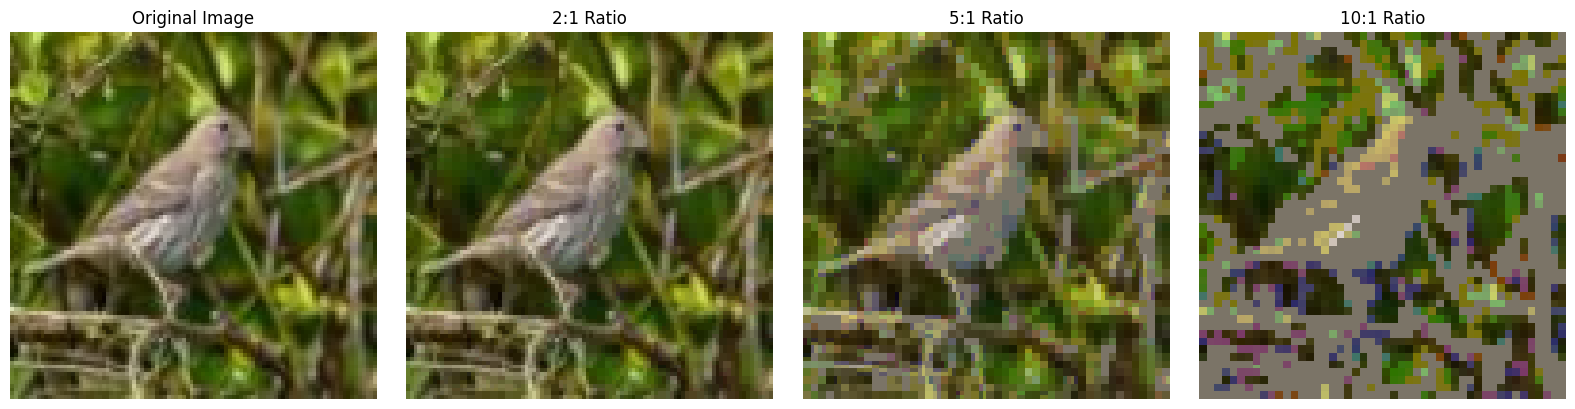

In [41]:
import matplotlib.pyplot as plt

def visualize_compression(image_tensor):
    # Un-normalize the original image for viewing (reversing the transform)
    img = image_tensor.cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    # Generate the compressed versions
    comp_2 = compress_image_wavelet(image_tensor, 2)
    comp_5 = compress_image_wavelet(image_tensor, 5)
    comp_10 = compress_image_wavelet(image_tensor, 10)

    # Un-normalize the compressed images so they look normal
    comp_2 = torch.clamp(comp_2 * std + mean, 0, 1)
    comp_5 = torch.clamp(comp_5 * std + mean, 0, 1)
    comp_10 = torch.clamp(comp_10 * std + mean, 0, 1)

    # Plot them side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Convert from PyTorch [C,H,W] to Matplotlib [H,W,C] format
    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(comp_2.permute(1, 2, 0))
    axes[1].set_title("2:1 Ratio")
    axes[1].axis('off')

    axes[2].imshow(comp_5.permute(1, 2, 0))
    axes[2].set_title("5:1 Ratio")
    axes[2].axis('off')

    axes[3].imshow(comp_10.permute(1, 2, 0))
    axes[3].set_title("10:1 Ratio")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# Grab a single batch from the test loader and visualize the first image
dataiter = iter(test_loader)
images, labels = next(dataiter)
visualize_compression(images[0])

# Phase 3

In [43]:
import os
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image

# We will use 10:1 since that's where the baseline model failed completely
TARGET_RATIO = 10
source_dir = './mini_imagenet_fixed/train'
target_dir = f'./mini_imagenet_compressed_{TARGET_RATIO}/train'

print(f"Creating compressed training set at {TARGET_RATIO}:1 ratio...")

# Create the target directory structure
os.makedirs(target_dir, exist_ok=True)
for class_name in os.listdir(source_dir):
    os.makedirs(os.path.join(target_dir, class_name), exist_ok=True)

# A simple transform just to load the images as tensors
load_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

# Load the uncompressed training set (without normalization for saving purposes)
raw_train_dataset = ImageFolder(source_dir, transform=load_transform)
raw_train_loader = DataLoader(raw_train_dataset, batch_size=1, shuffle=False)

# Process and save each image
for i, (img_tensor, label) in enumerate(raw_train_loader):
    # Get the class name and original file name
    class_name = raw_train_dataset.classes[label.item()]
    original_path, _ = raw_train_dataset.samples[i]
    file_name = os.path.basename(original_path)

    # Compress the image using your existing wavelet function
    # img_tensor is [1, C, H, W], so we pass img_tensor[0] to the function
    compressed_tensor = compress_image_wavelet(img_tensor[0], TARGET_RATIO)

    # Ensure values are valid for saving
    compressed_tensor = torch.clamp(compressed_tensor, 0, 1)

    # Save the compressed image to the new folder
    save_path = os.path.join(target_dir, class_name, file_name)
    save_image(compressed_tensor, save_path)

    if (i + 1) % 5000 == 0:
        print(f"Processed {i + 1}/{len(raw_train_dataset)} images...")

print(f"Finished generating compressed training set in: {target_dir}")

Creating compressed training set at 10:1 ratio...
Processed 5000/50000 images...
Processed 10000/50000 images...
Processed 15000/50000 images...
Processed 20000/50000 images...
Processed 25000/50000 images...
Processed 30000/50000 images...
Processed 35000/50000 images...
Processed 40000/50000 images...
Processed 45000/50000 images...
Processed 50000/50000 images...
Finished generating compressed training set in: ./mini_imagenet_compressed_10/train


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import time

# 1. Load the newly generated Compressed Training Data
comp_train_dir = './mini_imagenet_compressed_10/train'
# We reuse the `transform` from earlier (resize to 96x96 + normalize)
comp_train_dataset = ImageFolder(comp_train_dir, transform=transform)
comp_train_loader = DataLoader(comp_train_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Successfully loaded {len(comp_train_dataset)} compressed training images.")

# 2. Initialize a BRAND NEW Model (The "Vaccinated" Model)
comp_model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = comp_model.fc.in_features
comp_model.fc = nn.Linear(num_ftrs, 100)
comp_model = comp_model.to(device) # Send it to the GPU

# 3. Setup Optimizer and Loss (Using the 0.0001 learning rate that worked perfectly last time)
criterion = nn.CrossEntropyLoss()
comp_optimizer = optim.Adam(comp_model.parameters(), lr=0.0001)

num_epochs = 5
best_comp_val_acc = 0.0

print("Starting training on COMPRESSED data...")

# 4. The Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    comp_model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for inputs, labels in comp_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        comp_optimizer.zero_grad()
        outputs = comp_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        comp_optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # --- VALIDATION PHASE ---
    # We will use your existing val_loader (uncompressed) just to monitor general learning
    comp_model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = comp_model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.0f}s | "
          f"Train Loss: {running_loss/len(comp_train_loader):.4f}, Train Acc: {train_acc:.2f}% ")

    if val_acc > best_comp_val_acc:
        best_comp_val_acc = val_acc
        torch.save(comp_model.state_dict(), 'best_resnet18_compressed.pth')
        print("  --> Saved new best compressed model!")

print("Finished Training Compressed Model.")

Successfully loaded 50000 compressed training images.
Starting training on COMPRESSED data...
Epoch [1/5] | Time: 53s | Train Loss: 2.9513, Train Acc: 30.34% 
  --> Saved new best compressed model!
Epoch [2/5] | Time: 51s | Train Loss: 1.8044, Train Acc: 53.95% 
  --> Saved new best compressed model!
Epoch [3/5] | Time: 53s | Train Loss: 1.1157, Train Acc: 71.35% 
  --> Saved new best compressed model!
Epoch [4/5] | Time: 53s | Train Loss: 0.5500, Train Acc: 87.22% 
  --> Saved new best compressed model!
Epoch [5/5] | Time: 52s | Train Loss: 0.2083, Train Acc: 96.24% 
Finished Training Compressed Model.


In [53]:
# Load the best weights from Epoch 4
comp_model.load_state_dict(torch.load('best_resnet18_compressed.pth'))
comp_model.eval()

correct_comp = 0
total_comp = 0

print("Moment of Truth: Evaluating Vaccinated Model on 10:1 Compressed Test Set...")

with torch.no_grad():
    for inputs, labels in test_loader: # Using your fixed test_loader!
        # Compress the test images to 10:1 on the fly
        comp_inputs = torch.stack([compress_image_wavelet(img, 10) for img in inputs]).to(device)
        labels = labels.to(device)

        outputs = comp_model(comp_inputs)
        _, predicted = torch.max(outputs.data, 1)

        total_comp += labels.size(0)
        correct_comp += (predicted == labels).sum().item()

test_acc = 100 * correct_comp / total_comp
print(f"Vaccinated Model Accuracy on 10:1 Compressed Data: {test_acc:.2f}%")
print(f"Improvement over Baseline (13. something%): {test_acc - 13.60:.2f}%")

Moment of Truth: Evaluating Vaccinated Model on 10:1 Compressed Test Set...
Vaccinated Model Accuracy on 10:1 Compressed Data: 27.44%
Improvement over Baseline (13. something%): 13.84%


#Phase 1 (MobileNet)

In [47]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# 1. Initialize pre-trained MobileNetV2
mobilenet_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# 2. Modify the final classifier layer for 100 Mini-ImageNet classes
# MobileNetV2 uses a Sequential block for its classifier. The last layer is a Linear layer at index 1.
num_ftrs_mobilenet = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier[1] = nn.Linear(num_ftrs_mobilenet, 100)
mobilenet_model = mobilenet_model.to(device)

print("MobileNetV2 initialized and adapted for 100 classes.")

MobileNetV2 initialized and adapted for 100 classes.


In [48]:
import time

# 1. Setup Optimizer and Loss for MobileNet
criterion = nn.CrossEntropyLoss()
# MobileNet sometimes trains better with a slightly higher learning rate than ResNet
mobilenet_optimizer = optim.Adam(mobilenet_model.parameters(), lr=0.001)

num_epochs = 5
best_mobile_val_acc = 0.0

print("Starting Baseline Training for MobileNetV2...")

# 2. The Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    mobilenet_model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for inputs, labels in train_loader: # Back to the original uncompressed training data!
        inputs, labels = inputs.to(device), labels.to(device)

        mobilenet_optimizer.zero_grad()
        outputs = mobilenet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        mobilenet_optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # --- VALIDATION PHASE ---
    mobilenet_model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mobilenet_model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.0f}s | "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_mobile_val_acc:
        best_mobile_val_acc = val_acc
        torch.save(mobilenet_model.state_dict(), 'best_mobilenet_baseline.pth')
        print("  --> Saved new best MobileNet model!")

print("Finished Training Baseline MobileNet.")

Starting Baseline Training for MobileNetV2...
Epoch [1/5] | Time: 54s | Train Loss: 1.7407, Train Acc: 55.14% | Val Loss: 1.3752, Val Acc: 63.09%
  --> Saved new best MobileNet model!
Epoch [2/5] | Time: 57s | Train Loss: 1.1738, Train Acc: 67.40% | Val Loss: 1.3532, Val Acc: 64.31%
  --> Saved new best MobileNet model!
Epoch [3/5] | Time: 61s | Train Loss: 0.9560, Train Acc: 72.67% | Val Loss: 1.3140, Val Acc: 65.83%
  --> Saved new best MobileNet model!
Epoch [4/5] | Time: 54s | Train Loss: 0.8003, Train Acc: 76.66% | Val Loss: 1.3963, Val Acc: 64.53%
Epoch [5/5] | Time: 54s | Train Loss: 0.6879, Train Acc: 79.52% | Val Loss: 1.4226, Val Acc: 65.11%
Finished Training Baseline MobileNet.


In [49]:
# Load the correct best weights for MobileNet
mobilenet_model.load_state_dict(torch.load('best_mobilenet_baseline.pth'))
mobilenet_model.eval() # Set to evaluation mode

correct_test = 0
total_test = 0

print("Evaluating baseline model on the uncompressed test set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = mobilenet_model(inputs)

        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_acc = 100 * correct_test / total_test
print(f"Baseline Test Accuracy: {test_acc:.2f}%")

Evaluating baseline model on the uncompressed test set...
Baseline Test Accuracy: 64.24%


#Phase 2(MobileNet)

In [50]:
import pywt
import numpy as np
import torch

def compress_image_wavelet(image_tensor, ratio):
    """
    Compresses a PyTorch image tensor using 2D Haar Wavelet transform.
    Applies hard thresholding based on the desired compression ratio.
    """
    # Convert tensor to numpy array [C, H, W]
    img_np = image_tensor.cpu().numpy()
    C, H, W = img_np.shape

    compressed_img = np.zeros_like(img_np)

    # Process each color channel (RGB) separately
    for c in range(C):
        channel = img_np[c]

        # Perform 2D Discrete Wavelet Transform
        coeffs = pywt.dwt2(channel, 'haar')
        cA, (cH, cV, cD) = coeffs

        # Flatten all coefficients to find the threshold value
        all_coeffs = np.concatenate((cA.flatten(), cH.flatten(), cV.flatten(), cD.flatten()))

        # Calculate how many coefficients to keep based on the ratio
        total_coeffs = len(all_coeffs)
        kept_coeffs = max(1, int(total_coeffs / ratio)) # Keep at least 1 to avoid errors

        # Find the threshold value (the value below which we zero out)
        sorted_abs_coeffs = np.sort(np.abs(all_coeffs))
        threshold = sorted_abs_coeffs[-kept_coeffs]

        # Apply hard thresholding (zero out coefficients below threshold)
        cA_thresh = pywt.threshold(cA, threshold, mode='hard')
        cH_thresh = pywt.threshold(cH, threshold, mode='hard')
        cV_thresh = pywt.threshold(cV, threshold, mode='hard')
        cD_thresh = pywt.threshold(cD, threshold, mode='hard')

        # Reconstruct the channel using Inverse DWT
        reconstructed_channel = pywt.idwt2((cA_thresh, (cH_thresh, cV_thresh, cD_thresh)), 'haar')

        # Put back into our image array
        compressed_img[c] = reconstructed_channel[:H, :W]

    return torch.from_numpy(compressed_img).float()


# --- Evaluate Model on Compressed Images ---
compression_ratios = [2, 5, 10]

print("Starting Wavelet Compression Evaluation...")

for ratio in compression_ratios:
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader: # Using your fixed test_loader

            # Compress the batch of images one by one
            compressed_inputs = torch.stack([compress_image_wavelet(img, ratio) for img in inputs])

            # Move compressed images and labels to GPU
            compressed_inputs = compressed_inputs.to(device)
            labels = labels.to(device)

            # Run model predictions
            outputs = mobilenet_model(compressed_inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Compression Ratio {ratio}:1 -> Test Accuracy: {accuracy:.2f}%")

Starting Wavelet Compression Evaluation...
Compression Ratio 2:1 -> Test Accuracy: 62.97%
Compression Ratio 5:1 -> Test Accuracy: 22.66%
Compression Ratio 10:1 -> Test Accuracy: 8.16%


In [51]:
import torch

def analyze_class_degradation(model, test_loader, class_names, ratio=10):
    print(f"Starting per-class analysis at {ratio}:1 compression ratio. This might take a few minutes...")
    model.eval()

    # Dictionaries to track correct predictions
    correct_base = {classname: 0 for classname in class_names}
    correct_comp = {classname: 0 for classname in class_names}
    total_class = {classname: 0 for classname in class_names}

    with torch.no_grad():
        for inputs, labels in test_loader:
            # 1. Evaluate uncompressed batch
            inputs, labels = inputs.to(device), labels.to(device)
            outputs_base = model(inputs)
            _, preds_base = torch.max(outputs_base, 1)

            # 2. Evaluate compressed batch
            comp_inputs = torch.stack([compress_image_wavelet(img, ratio) for img in inputs]).to(device)
            outputs_comp = model(comp_inputs)
            _, preds_comp = torch.max(outputs_comp, 1)

            # 3. Tally results per class
            for label, p_base, p_comp in zip(labels, preds_base, preds_comp):
                classname = class_names[label.item()]
                total_class[classname] += 1

                if p_base == label:
                    correct_base[classname] += 1
                if p_comp == label:
                    correct_comp[classname] += 1

    # Calculate the accuracy drop for each class
    class_drops = {}
    for classname in class_names:
        if total_class[classname] > 0: # Avoid division by zero
            acc_base = 100 * correct_base[classname] / total_class[classname]
            acc_comp = 100 * correct_comp[classname] / total_class[classname]
            class_drops[classname] = {
                'base_acc': acc_base,
                'comp_acc': acc_comp,
                'drop': acc_base - acc_comp
            }

    # Sort the dictionary by the highest drop in accuracy
    sorted_drops = sorted(class_drops.items(), key=lambda x: x[1]['drop'], reverse=True)

    print("\n--- TOP 5 MOST AFFECTED CLASSES ---")
    for classname, stats in sorted_drops[:5]:
        print(f"Class: {classname:15s} | Drop: {stats['drop']:5.1f}% (Base: {stats['base_acc']:4.1f}% -> Comp: {stats['comp_acc']:4.1f}%)")

    print("\n--- TOP 5 MOST ROBUST CLASSES ---")
    for classname, stats in sorted_drops[-5:]:
        print(f"Class: {classname:15s} | Drop: {stats['drop']:5.1f}% (Base: {stats['base_acc']:4.1f}% -> Comp: {stats['comp_acc']:4.1f}%)")

# Extract class names from your fixed test dataset
class_list = test_dataset.classes
analyze_class_degradation(mobilenet_model, test_loader, class_list, ratio=10)

Starting per-class analysis at 10:1 compression ratio. This might take a few minutes...

--- TOP 5 MOST AFFECTED CLASSES ---
Class: n03417042       | Drop:  90.0% (Base: 90.0% -> Comp:  0.0%)
Class: n02110341       | Drop:  89.0% (Base: 89.0% -> Comp:  0.0%)
Class: n07697537       | Drop:  85.0% (Base: 85.0% -> Comp:  0.0%)
Class: n02174001       | Drop:  84.0% (Base: 84.0% -> Comp:  0.0%)
Class: n07613480       | Drop:  81.0% (Base: 81.0% -> Comp:  0.0%)

--- TOP 5 MOST ROBUST CLASSES ---
Class: n04275548       | Drop:  19.0% (Base: 66.0% -> Comp: 47.0%)
Class: n03998194       | Drop:  14.0% (Base: 35.0% -> Comp: 21.0%)
Class: n03400231       | Drop:  13.0% (Base: 13.0% -> Comp:  0.0%)
Class: n02971356       | Drop:  10.0% (Base: 52.0% -> Comp: 42.0%)
Class: n03337140       | Drop:   5.0% (Base: 64.0% -> Comp: 59.0%)


#Phase 3 (MobileNet)

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import time

# 1. Load the newly generated Compressed Training Data
comp_train_dir = './mini_imagenet_compressed_10/train'
# We reuse the `transform` from earlier (resize to 96x96 + normalize)
comp_train_dataset = ImageFolder(comp_train_dir, transform=transform)
comp_train_loader = DataLoader(comp_train_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Successfully loaded {len(comp_train_dataset)} compressed training images.")

# 2. Initialize a BRAND NEW MobileNet Model (The "Vaccinated" Model)
comp_mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Modify the final classifier layer for 100 Mini-ImageNet classes
num_ftrs = comp_mobilenet.classifier[1].in_features
comp_mobilenet.classifier[1] = nn.Linear(num_ftrs, 100)
comp_mobilenet = comp_mobilenet.to(device) # Send it to the GPU

# 3. Setup Optimizer and Loss
criterion = nn.CrossEntropyLoss()
comp_optimizer = optim.Adam(comp_mobilenet.parameters(), lr=0.001)

num_epochs = 5
best_comp_val_acc = 0.0

print("Starting training on COMPRESSED data for MobileNetV2...")

# 4. The Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    comp_mobilenet.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for inputs, labels in comp_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        comp_optimizer.zero_grad()
        outputs = comp_mobilenet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        comp_optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # --- VALIDATION PHASE ---
    # We will use your perfectly split val_loader (uncompressed) just to monitor general learning
    comp_mobilenet.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = comp_mobilenet(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    epoch_time = time.time() - start_time
    # Fixed print statement to show validation metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.0f}s | "
          f"Train Loss: {running_loss/len(comp_train_loader):.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_comp_val_acc:
        best_comp_val_acc = val_acc
        torch.save(comp_mobilenet.state_dict(), 'best_mobilenet_compressed.pth')
        print("  --> Saved new best compressed model!")

print("Finished Training Compressed MobileNet.")

Successfully loaded 50000 compressed training images.
Starting training on COMPRESSED data for MobileNetV2...
Epoch [1/5] | Time: 61s | Train Loss: 2.8310, Train Acc: 30.74% | Val Loss: 2.3003, Val Acc: 41.04%
  --> Saved new best compressed model!
Epoch [2/5] | Time: 62s | Train Loss: 2.1646, Train Acc: 44.14% | Val Loss: 1.9536, Val Acc: 49.36%
  --> Saved new best compressed model!
Epoch [3/5] | Time: 60s | Train Loss: 1.8710, Train Acc: 50.31% | Val Loss: 1.8315, Val Acc: 52.47%
  --> Saved new best compressed model!
Epoch [4/5] | Time: 60s | Train Loss: 1.6591, Train Acc: 55.32% | Val Loss: 1.8603, Val Acc: 53.08%
  --> Saved new best compressed model!
Epoch [5/5] | Time: 60s | Train Loss: 1.4590, Train Acc: 59.71% | Val Loss: 1.5881, Val Acc: 58.90%
  --> Saved new best compressed model!
Finished Training Compressed MobileNet.


In [55]:
# The Moment of Truth for MobileNet!
comp_mobilenet.load_state_dict(torch.load('best_mobilenet_compressed.pth'))
comp_mobilenet.eval()

correct_comp = 0
total_comp = 0

print("Evaluating Vaccinated MobileNet on 10:1 Compressed Test Set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        # Compress the test images to 10:1 on the fly
        comp_inputs = torch.stack([compress_image_wavelet(img, 10) for img in inputs]).to(device)
        labels = labels.to(device)

        outputs = comp_mobilenet(comp_inputs)
        _, predicted = torch.max(outputs.data, 1)

        total_comp += labels.size(0)
        correct_comp += (predicted == labels).sum().item()

test_acc = 100 * correct_comp / total_comp
print(f"Vaccinated MobileNet Accuracy on 10:1 Compressed Data: {test_acc:.2f}%")

Evaluating Vaccinated MobileNet on 10:1 Compressed Test Set...
Vaccinated MobileNet Accuracy on 10:1 Compressed Data: 26.19%
